# Monetization Analysis

## Objective

In this notebook, I analyze the game's monetization with purchase data from registered users.

My goal is to understand:

- the main revenue, payer, and purchase KPIs
- payer conversion, ARPU, ARPPU, and ARPDAU
- cohort-based D30 ARPU for users with a full 30-day window
- how revenue changes over time
- how often users buy and how fast they make the first purchase
- which OS and country groups look stronger
- how much revenue comes from higher-value payer segments

I also keep the scope clear:

- user-level monetization uses purchase rows matched to `users`
- lifecycle monetization uses users whose `join_date` is inside the purchase window


In [39]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.2f}'.format
plt.style.use('seaborn-v0_8-whitegrid')


## 1. Load data and analysis scope

I use `users`, `user_sessions`, and `user_purchases` in this notebook.

Important scope notes:

- I keep valid purchase rows, including repeated rows
- user-level monetization metrics use only purchase rows that match a registered user in `users`
- payer conversion uses registered users as the denominator
- daily revenue trends in this notebook use only purchase rows from registered users
- lifecycle monetization metrics such as `days_to_first_purchase` use only registered users whose `join_date` is inside the purchase data window
- cohort-based `D30 ARPU` also needs users with a full 30-day observation window


In [40]:
data_dir = Path('csv_files')

users = pd.read_csv(data_dir / 'users.csv')
sessions = pd.read_csv(data_dir / 'user_sessions.csv')
purchases = pd.read_csv(data_dir / 'user_purchases.csv')

users['user_id'] = pd.to_numeric(users['user_id'], errors='coerce').astype('Int64')
users['join_date'] = pd.to_datetime(users['join_date'], errors='coerce').dt.normalize()
users['country'] = users['country'].fillna('Unknown')
users['os'] = users['os'].fillna('Unknown')

sessions['user_id'] = pd.to_numeric(sessions['user_id'], errors='coerce').astype('Int64')
sessions['dt'] = pd.to_datetime(sessions['dt'], errors='coerce').dt.normalize()
sessions['session_duration_sec'] = pd.to_numeric(sessions['session_duration_sec'], errors='coerce')

purchases['user_id'] = pd.to_numeric(purchases['user_id'], errors='coerce').astype('Int64')
purchases['dt'] = pd.to_datetime(purchases['dt'], errors='coerce').dt.normalize()
purchases['price_usd'] = pd.to_numeric(purchases['price_usd'], errors='coerce')

users_clean = users.drop_duplicates(subset=['user_id']).copy()
sessions_clean = sessions[sessions['user_id'].isin(users_clean['user_id'])].copy()
sessions_clean = sessions_clean[
    sessions_clean['dt'].notna() &
    sessions_clean['session_duration_sec'].notna() &
    (sessions_clean['session_duration_sec'] >= 0)
].copy()

purchases_valid = purchases[
    purchases['dt'].notna() &
    purchases['price_usd'].notna() &
    (purchases['price_usd'] > 0)
].copy()

purchases_valid['matched_user'] = purchases_valid['user_id'].isin(users_clean['user_id'])
purchases_matched = purchases_valid[purchases_valid['matched_user']].copy()

purchase_start = purchases_matched['dt'].min()
purchase_end = purchases_matched['dt'].max()

lifecycle_users = users_clean[
    users_clean['join_date'].between(purchase_start, purchase_end)
].copy()

scope_df = pd.DataFrame(
    {
        'metric': [
            'users in users table (registered users)',
            'raw purchase rows',
            'valid purchase rows',
            'purchase rows from registered users',
            'purchase revenue from registered users',
            'purchase window start',
            'purchase window end',
            'registered users inside purchase window',
        ],
        'value': [
            users_clean['user_id'].nunique(dropna=True),
            len(purchases),
            len(purchases_valid),
            len(purchases_matched),
            round(purchases_matched['price_usd'].sum(), 2),
            purchase_start.date(),
            purchase_end.date(),
            lifecycle_users['user_id'].nunique(dropna=True),
        ],
    }
)

display(scope_df)


,metric,value
0,users in users table (registered users),6584
1,raw purchase rows,236270
2,valid purchase rows,236161
3,purchase rows from registered users,146572
4,purchase revenue from registered users,"693,064.63"
5,purchase window start,2022-06-02
6,purchase window end,2022-12-28
7,registered users inside purchase window,4268


### Comment

- This notebook keeps valid purchase rows and does not remove repeated full rows. I do this because the purchase table does not have `purchase_id`, `session_id`, or time-level timestamp. Because of that, some repeated rows may be true repeated purchases from the same user on the same day.
- I still limit user-level monetization to purchase rows that match a registered user in `users`.
- For lifecycle monetization, I also need a smaller user base because users who joined before the purchase window do not have a full early purchase history.


## 2. Monetization metric definitions

I use these basic monetization metrics in the notebook:

- `paying user`: a purchase made by a registered user
- `payer conversion`: paying users / total registered users
- `ARPU`: total revenue / total registered users
- `ARPPU`: total revenue / paying users
- `D30 ARPU`: first 30-day revenue / users with a full 30-day observation window
- `ARPDAU`: daily revenue / daily active users
- `purchase frequency`: total purchases / paying users
- `revenue per purchase`: total revenue / number of purchases

Important note:

- `ARPU` uses all registered users in the `users` table
- `ARPPU` uses only registered users who have at least one purchase
- `D30 ARPU` uses eligible lifecycle users with the same first 30 days after join
- `ARPDAU` uses daily revenue from registered users and daily active users from session activity


## 3. Purchase data preparation

Now I build the user-level monetization tables that I will use in the rest of the notebook.


In [41]:
purchase_user_summary = (
    purchases_matched
    .groupby('user_id')
    .agg(
        total_revenue=('price_usd', 'sum'),
        purchase_count=('price_usd', 'size'),
        first_purchase_date=('dt', 'min'),
        last_purchase_date=('dt', 'max'),
        avg_revenue_per_purchase=('price_usd', 'mean'),
    )
    .reset_index()
)

user_monetization = users_clean[['user_id', 'join_date', 'os', 'country']].merge(
    purchase_user_summary,
    on='user_id',
    how='left'
)

user_monetization['is_payer'] = user_monetization['purchase_count'].fillna(0).gt(0)
user_monetization['total_revenue'] = user_monetization['total_revenue'].fillna(0)
user_monetization['purchase_count'] = user_monetization['purchase_count'].fillna(0).astype(int)
user_monetization['days_to_first_purchase'] = (
    user_monetization['first_purchase_date'] - user_monetization['join_date']
).dt.days

lifecycle_monetization = lifecycle_users[['user_id', 'join_date', 'os', 'country']].merge(
    purchase_user_summary,
    on='user_id',
    how='left'
)
lifecycle_monetization['is_payer'] = lifecycle_monetization['purchase_count'].fillna(0).gt(0)
lifecycle_monetization['total_revenue'] = lifecycle_monetization['total_revenue'].fillna(0)
lifecycle_monetization['purchase_count'] = lifecycle_monetization['purchase_count'].fillna(0).astype(int)
lifecycle_monetization['days_to_first_purchase'] = (
    lifecycle_monetization['first_purchase_date'] - lifecycle_monetization['join_date']
).dt.days

prep_df = pd.DataFrame(
    {
        'metric': [
            'payers in registered users',
            'non-payers in registered users',
            'avg revenue per purchase',
        ],
        'value': [
            user_monetization['is_payer'].sum(),
            (~user_monetization['is_payer']).sum(),
            purchases_matched['price_usd'].mean(),
        ],
    }
)

display(prep_df)
display(user_monetization[['user_id', 'total_revenue', 'purchase_count', 'first_purchase_date', 'days_to_first_purchase']].head(10))


,metric,value
0,payers in registered users,"6,270.00"
1,non-payers in registered users,314.00
2,avg revenue per purchase,4.73


,user_id,total_revenue,purchase_count,first_purchase_date,days_to_first_purchase
0,157844,84.77,23,2022-08-07,245.00
1,583785,327.21,12,2022-06-25,0.00
2,152828,0.00,0,NaT,NaN
3,948940,126.61,21,2022-09-19,0.00
4,1141021,101.82,15,2022-12-25,0.00
5,535442,80.10,18,2022-08-08,66.00
6,910913,38.87,13,2022-09-09,0.00
7,695371,51.72,18,2022-10-21,85.00
8,159017,123.83,17,2022-08-11,248.00
9,721930,36.88,12,2022-08-02,0.00


### Comment

- In this notebook, repeated full purchase rows are kept because they may be true repeat purchases. This means revenue and purchase count stay closer to the raw purchase log.

## 4. Overall monetization overview

This section gives the main monetization KPIs for the matched purchase scope.


In [42]:
total_users = user_monetization['user_id'].nunique()
total_payers = int(user_monetization['is_payer'].sum())
total_revenue = user_monetization['total_revenue'].sum()
total_purchases = purchases_matched.shape[0]

kpi_df = pd.DataFrame(
    {
        'metric': [
            'total revenue',
            'total purchases',
            'total paying users',
            'payer conversion',
            'ARPU',
            'ARPPU',
            'purchases per payer',
            'revenue per purchase',
        ],
        'value': [
            total_revenue,
            total_purchases,
            total_payers,
            total_payers / total_users,
            total_revenue / total_users,
            total_revenue / total_payers,
            total_purchases / total_payers,
            total_revenue / total_purchases,
        ],
    }
)

kpi_df['value'] = kpi_df['value'].round(2)
display(kpi_df)


,metric,value
0,total revenue,"693,064.63"
1,total purchases,"146,572.00"
2,total paying users,"6,270.00"
3,payer conversion,0.95
4,ARPU,105.26
5,ARPPU,110.54
6,purchases per payer,23.38
7,revenue per purchase,4.73


### Comment

- Total revenue is about 693K from about 147K purchases.
- Payer conversion is still very high in this dataset.
- ARPU is also high, but it uses all observed revenue in the purchase window. This is not a fixed D30-style metric, so older users had more time to spend than newer users.
- Because payer conversion is already very high, ARPPU and purchase frequency become more useful to understand spend depth.


## 5. Revenue trend over time

Here I look at how daily monetization moves over time, including ARPDAU and monthly average ARPDAU.


,metric,value
0,avg daily revenue,"3,300.31"
1,median daily revenue,"3,310.23"
2,max daily revenue,"5,633.28"
3,avg daily paying users,403.93
4,avg revenue per payer,8.31
5,avg daily ARPDAU,1.17


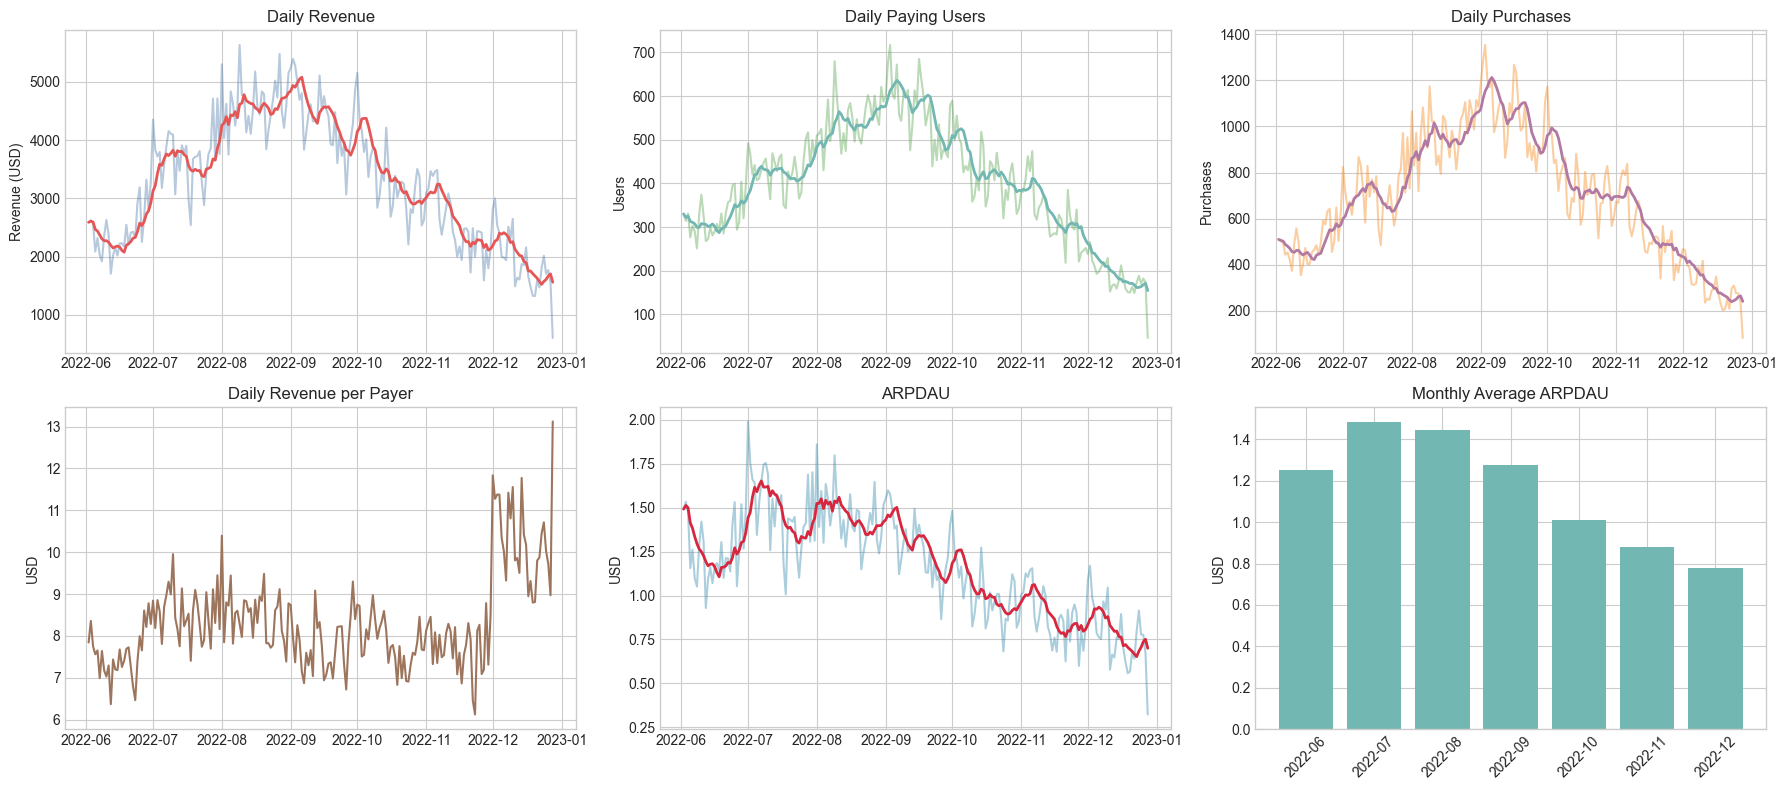

In [43]:
daily_revenue = (
    purchases_matched
    .groupby('dt')
    .agg(
        revenue=('price_usd', 'sum'),
        purchases=('price_usd', 'size'),
        paying_users=('user_id', 'nunique'),
    )
    .reset_index()
)

daily_dau = (
    sessions_clean
    .groupby('dt')
    .agg(dau=('user_id', 'nunique'))
    .reset_index()
)

daily_revenue = daily_dau.merge(daily_revenue, on='dt', how='left')
daily_revenue[['revenue', 'purchases', 'paying_users']] = daily_revenue[['revenue', 'purchases', 'paying_users']].fillna(0)
daily_revenue['purchases'] = daily_revenue['purchases'].astype(int)
daily_revenue['paying_users'] = daily_revenue['paying_users'].astype(int)

daily_revenue['revenue_7d_ma'] = daily_revenue['revenue'].rolling(7, min_periods=1).mean()
daily_revenue['purchases_7d_ma'] = daily_revenue['purchases'].rolling(7, min_periods=1).mean()
daily_revenue['paying_users_7d_ma'] = daily_revenue['paying_users'].rolling(7, min_periods=1).mean()
daily_revenue['revenue_per_payer'] = np.where(
    daily_revenue['paying_users'] > 0,
    daily_revenue['revenue'] / daily_revenue['paying_users'],
    np.nan,
)
daily_revenue['arpdau'] = daily_revenue['revenue'] / daily_revenue['dau']
daily_revenue['arpdau_7d_ma'] = daily_revenue['arpdau'].rolling(7, min_periods=1).mean()

daily_revenue['month'] = daily_revenue['dt'].dt.to_period('M').dt.to_timestamp()
monthly_arpdau = (
    daily_revenue
    .groupby('month')
    .agg(avg_arpdau=('arpdau', 'mean'))
    .reset_index()
)
monthly_arpdau['month_label'] = monthly_arpdau['month'].dt.strftime('%Y-%m')

trend_summary = pd.DataFrame(
    {
        'metric': [
            'avg daily revenue',
            'median daily revenue',
            'max daily revenue',
            'avg daily paying users',
            'avg revenue per payer',
            'avg daily ARPDAU',
        ],
        'value': [
            daily_revenue['revenue'].mean(),
            daily_revenue['revenue'].median(),
            daily_revenue['revenue'].max(),
            daily_revenue['paying_users'].mean(),
            daily_revenue['revenue_per_payer'].mean(),
            daily_revenue['arpdau'].mean(),
        ],
    }
)
trend_summary['value'] = trend_summary['value'].round(2)

display(trend_summary)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

axes[0, 0].plot(daily_revenue['dt'], daily_revenue['revenue'], color='#4C78A8', alpha=0.4)
axes[0, 0].plot(daily_revenue['dt'], daily_revenue['revenue_7d_ma'], color='#E45756', linewidth=2)
axes[0, 0].set_title('Daily Revenue')
axes[0, 0].set_ylabel('Revenue (USD)')

axes[0, 1].plot(daily_revenue['dt'], daily_revenue['paying_users'], color='#54A24B', alpha=0.4)
axes[0, 1].plot(daily_revenue['dt'], daily_revenue['paying_users_7d_ma'], color='#72B7B2', linewidth=2)
axes[0, 1].set_title('Daily Paying Users')
axes[0, 1].set_ylabel('Users')

axes[0, 2].plot(daily_revenue['dt'], daily_revenue['purchases'], color='#F58518', alpha=0.4)
axes[0, 2].plot(daily_revenue['dt'], daily_revenue['purchases_7d_ma'], color='#B279A2', linewidth=2)
axes[0, 2].set_title('Daily Purchases')
axes[0, 2].set_ylabel('Purchases')

axes[1, 0].plot(daily_revenue['dt'], daily_revenue['revenue_per_payer'], color='#9D755D')
axes[1, 0].set_title('Daily Revenue per Payer')
axes[1, 0].set_ylabel('USD')

axes[1, 1].plot(daily_revenue['dt'], daily_revenue['arpdau'], color='#2E86AB', alpha=0.4)
axes[1, 1].plot(daily_revenue['dt'], daily_revenue['arpdau_7d_ma'], color='#D7263D', linewidth=2)
axes[1, 1].set_title('ARPDAU')
axes[1, 1].set_ylabel('USD')

axes[1, 2].bar(monthly_arpdau['month_label'], monthly_arpdau['avg_arpdau'], color='#72B7B2')
axes[1, 2].set_title('Monthly Average ARPDAU')
axes[1, 2].set_ylabel('USD')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Comment

- Daily revenue, paying users, and daily purchases all grow from June to around early September. After that point, all three metrics go down step by step until the end of the period. This suggests that revenue changes are driven mostly by payer volume and purchase volume, not by a big change in spend per payer.
- ARPDAU also gets weaker after the summer peak, which means revenue per active user becomes lower later in the period.
- The monthly average ARPDAU chart shows the same pattern more clearly: it is stronger in July and August, then it goes down month by month through the end of the year.
- Daily revenue per payer stays in a narrower range than the other charts, but it becomes more volatile late in the period. The sharp drop on the last day should be read carefully because it may be an incomplete day in the data.


## 6. Payer conversion analysis

Payer conversion is one of the most basic monetization metrics in a mobile game. It means the share of users who made at least one purchase.

In simple words:
`payer conversion = paying users / total registered users`


,metric,value
0,overall payer conversion,95.23


,os,users,payers,payer_conversion
0,Android,4266,4103,0.96
1,iOS,2318,2167,0.93


,country,users,payers,payer_conversion
3,United Kingdom,1531,1369,0.89
4,United States,1439,1350,0.94
1,Germany,418,412,0.99
2,Spain,260,254,0.98
0,Chile,237,220,0.93


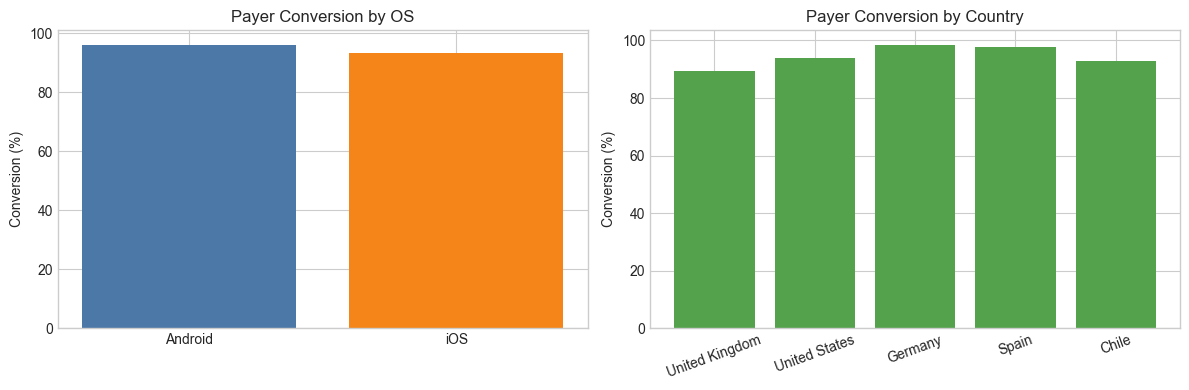

In [44]:
overall_conversion_df = pd.DataFrame(
    {
        'metric': ['overall payer conversion'],
        'value': [round(user_monetization['is_payer'].mean() * 100, 2)],
    }
)

os_conversion = (
    user_monetization
    .groupby('os')
    .agg(users=('user_id', 'nunique'), payers=('is_payer', 'sum'))
    .reset_index()
)
os_conversion['payer_conversion'] = os_conversion['payers'] / os_conversion['users']

top_country_list = user_monetization.loc[user_monetization['country'] != 'Unknown', 'country'].value_counts().head(5).index.tolist()
country_conversion = (
    user_monetization[user_monetization['country'].isin(top_country_list)]
    .groupby('country')
    .agg(users=('user_id', 'nunique'), payers=('is_payer', 'sum'))
    .reset_index()
)
country_conversion['payer_conversion'] = country_conversion['payers'] / country_conversion['users']
country_conversion = country_conversion.sort_values('users', ascending=False)

display(overall_conversion_df)
display(os_conversion[['os', 'users', 'payers', 'payer_conversion']])
display(country_conversion[['country', 'users', 'payers', 'payer_conversion']])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(os_conversion['os'], os_conversion['payer_conversion'] * 100, color=['#4C78A8', '#F58518'])
axes[0].set_title('Payer Conversion by OS')
axes[0].set_ylabel('Conversion (%)')

axes[1].bar(country_conversion['country'], country_conversion['payer_conversion'] * 100, color='#54A24B')
axes[1].set_title('Payer Conversion by Country')
axes[1].set_ylabel('Conversion (%)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


### Comment

- Overall payer conversion is 95.23% in the matched registered-user base. This is very high, but it is not the overall game conversion rate.
- The raw purchase file has many more users than the `users` table, so this notebook uses a selected user sample.
- Android conversion is 96.18%, while iOS conversion is 93.49%. The gap is not very large, but Android still looks a little stronger on conversion.
- Country differences are clearer. In the top-country group, Germany and Spain are close to 98% conversion, while the United Kingdom is lower at about 89%. This means conversion is not flat across markets. Some countries look much stronger at getting users to their first purchase.

## 7. ARPU and ARPPU breakdowns

Now I separate conversion from spend depth.


,os,ARPU,ARPPU
0,Android,102.63,106.71
1,iOS,110.11,117.78


,country,ARPU,ARPPU
3,United Kingdom,98.25,109.87
4,United States,129.06,137.57
1,Germany,144.52,146.63
2,Spain,104.46,106.93
0,Chile,79.00,85.11


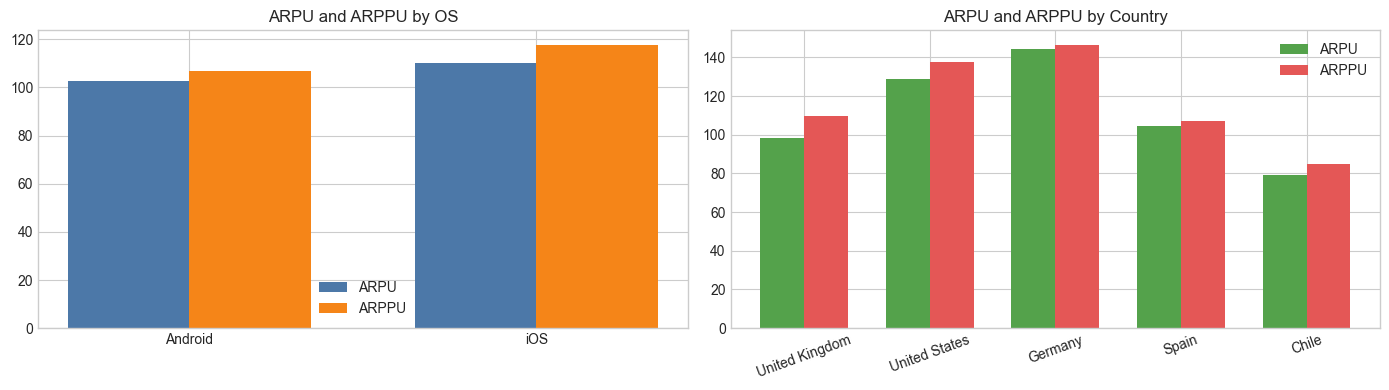

In [45]:
os_value_metrics = (
    user_monetization
    .groupby('os')
    .agg(
        users=('user_id', 'nunique'),
        payers=('is_payer', 'sum'),
        revenue=('total_revenue', 'sum'),
    )
    .reset_index()
)
os_value_metrics['ARPU'] = os_value_metrics['revenue'] / os_value_metrics['users']
os_value_metrics['ARPPU'] = os_value_metrics['revenue'] / os_value_metrics['payers']

country_value_metrics = (
    user_monetization[user_monetization['country'].isin(top_country_list)]
    .groupby('country')
    .agg(
        users=('user_id', 'nunique'),
        payers=('is_payer', 'sum'),
        revenue=('total_revenue', 'sum'),
    )
    .reset_index()
)
country_value_metrics['ARPU'] = country_value_metrics['revenue'] / country_value_metrics['users']
country_value_metrics['ARPPU'] = country_value_metrics['revenue'] / country_value_metrics['payers']
country_value_metrics = country_value_metrics.sort_values('users', ascending=False)

display(os_value_metrics[['os', 'ARPU', 'ARPPU']].round(2))
display(country_value_metrics[['country', 'ARPU', 'ARPPU']].round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x = np.arange(len(os_value_metrics))
width = 0.35
axes[0].bar(x - width / 2, os_value_metrics['ARPU'], width=width, label='ARPU', color='#4C78A8')
axes[0].bar(x + width / 2, os_value_metrics['ARPPU'], width=width, label='ARPPU', color='#F58518')
axes[0].set_xticks(x)
axes[0].set_xticklabels(os_value_metrics['os'])
axes[0].set_title('ARPU and ARPPU by OS')
axes[0].legend()

x = np.arange(len(country_value_metrics))
axes[1].bar(x - width / 2, country_value_metrics['ARPU'], width=width, label='ARPU', color='#54A24B')
axes[1].bar(x + width / 2, country_value_metrics['ARPPU'], width=width, label='ARPPU', color='#E45756')
axes[1].set_xticks(x)
axes[1].set_xticklabels(country_value_metrics['country'], rotation=20)
axes[1].set_title('ARPU and ARPPU by Country')
axes[1].legend()

plt.tight_layout()
plt.show()


### Comment

- Android has slightly better payer conversion, but iOS has stronger ARPU and ARPPU. This means iOS users in this dataset spend more on average, even though Android converts a little better.

## 8. Purchase frequency analysis

This section shows how often paying users make purchases.


In [46]:
payers_only = user_monetization[user_monetization['is_payer']].copy()

purchase_frequency_df = pd.DataFrame(
    {
        'metric': [
            'one-time payers',
            'repeat purchasers',
            'repeat purchaser rate',
            'avg purchases per payer',
            'median purchases per payer',
        ],
        'value': [
            (payers_only['purchase_count'] == 1).sum(),
            (payers_only['purchase_count'] >= 2).sum(),
            (payers_only['purchase_count'] >= 2).mean(),
            payers_only['purchase_count'].mean(),
            payers_only['purchase_count'].median(),
        ],
    }
)

payers_only['purchase_segment'] = pd.cut(
    payers_only['purchase_count'],
    bins=[0, 1, 3, np.inf],
    labels=['1 purchase', '2-3 purchases', '4+ purchases'],
)

purchase_segment_df = (
    payers_only
    .groupby('purchase_segment', observed=False)
    .agg(
        payers=('user_id', 'nunique'),
        revenue=('total_revenue', 'sum'),
        avg_revenue=('total_revenue', 'mean'),
    )
    .reset_index()
)
purchase_segment_df['payer_share'] = purchase_segment_df['payers'] / purchase_segment_df['payers'].sum()
purchase_segment_df['revenue_share'] = purchase_segment_df['revenue'] / purchase_segment_df['revenue'].sum()

display(purchase_frequency_df.round(2))
display(purchase_segment_df.round(3))

,metric,value
0,one-time payers,40.00
1,repeat purchasers,"6,230.00"
2,repeat purchaser rate,0.99
3,avg purchases per payer,23.38
4,median purchases per payer,17.00


,purchase_segment,payers,revenue,avg_revenue,payer_share,revenue_share
0,1 purchase,40,219.01,5.47,0.01,0.00
1,2-3 purchases,85,848.11,9.98,0.01,0.00
2,4+ purchases,6145,"691,997.51",112.61,0.98,1.00


### Comment

- This purchase base is very repeat-heavy. One-time payers are a very small group, while almost all payers are in the `4+ purchases` segment. Because of that, most revenue also comes from repeat purchasers.


## 9. First purchase behavior

This section uses the lifecycle monetization base, so it looks only at users whose `join_date` is inside the purchase data window.

In the first chart, I clip the distribution at the 95th percentile.
I do this because a small number of users have a much longer time to first purchase, and they make the chart harder to read for the main user group.


,metric,value
0,lifecycle users,"4,268.00"
1,lifecycle paying users,"4,268.00"
2,avg days to first purchase,8.81
3,median days to first purchase,3.00


,first_purchase_segment,payers,revenue,payer_share
0,Day 0,1137,"147,378.34",0.27
1,Day 1-3,1138,"135,163.73",0.27
2,Day 4-7,647,"70,070.26",0.15
3,Day 8+,1346,"146,626.34",0.32


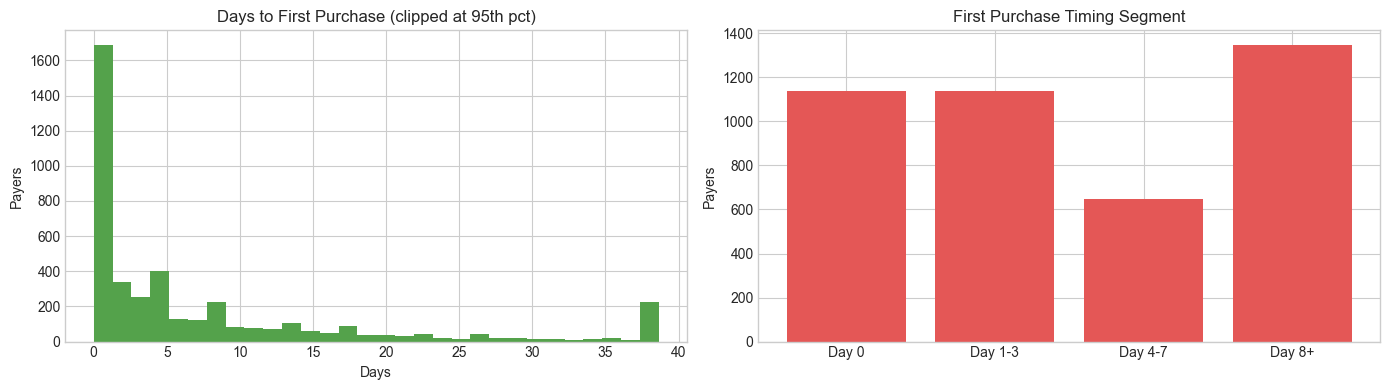

In [47]:
lifecycle_payers = lifecycle_monetization[lifecycle_monetization['is_payer']].copy()

first_purchase_summary = pd.DataFrame(
    {
        'metric': [
            'lifecycle users',
            'lifecycle paying users',
            'avg days to first purchase',
            'median days to first purchase',
        ],
        'value': [
            lifecycle_monetization['user_id'].nunique(),
            lifecycle_payers['user_id'].nunique(),
            lifecycle_payers['days_to_first_purchase'].mean(),
            lifecycle_payers['days_to_first_purchase'].median(),
        ],
    }
)

lifecycle_payers['first_purchase_segment'] = pd.cut(
    lifecycle_payers['days_to_first_purchase'],
    bins=[-np.inf, 0, 3, 7, np.inf],
    labels=['Day 0', 'Day 1-3', 'Day 4-7', 'Day 8+'],
)

first_purchase_segment_df = (
    lifecycle_payers
    .groupby('first_purchase_segment', observed=False)
    .agg(
        payers=('user_id', 'nunique'),
        revenue=('total_revenue', 'sum'),
    )
    .reset_index()
)
first_purchase_segment_df['payer_share'] = first_purchase_segment_df['payers'] / first_purchase_segment_df['payers'].sum()

clipped_days = lifecycle_payers['days_to_first_purchase'].clip(
    upper=lifecycle_payers['days_to_first_purchase'].quantile(0.95)
)

display(first_purchase_summary.round(2))
display(first_purchase_segment_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(clipped_days, bins=30, color='#54A24B')
axes[0].set_title('Days to First Purchase (clipped at 95th pct)')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Payers')

axes[1].bar(first_purchase_segment_df['first_purchase_segment'], first_purchase_segment_df['payers'], color='#E45756')
axes[1].set_title('First Purchase Timing Segment')
axes[1].set_ylabel('Payers')

plt.tight_layout()
plt.show()


### Comment

- The histogram shows a strong spike at the very beginning. Many payers make their first purchase on Day 0 or in the first few days after join. At the same time, the distribution still has a long right tail. This means some users wait much longer before their first purchase.
- In the segment chart, `Day 0` and `Day 1-3` are both large groups, and together they make up more than half of all lifecycle payers. `Day 4-7` is the smallest group, while `Day 8+` is still a large segment. So early conversion is very important, but late conversion also matters in this dataset. Overall, the chart suggests the first few days are a key monetization window, but not the only one.


## 10. D30 ARPU (cohort base)

I calculate D30 ARPU because raw ARPU mixes older users and newer users in the same purchase window.
A cohort-base D30 view gives each eligible user the same first 30 days after join, so the comparison is cleaner.
Here I use Day 0 to Day 29 after join.


,metric,value
0,eligible users,"4,230.00"
1,D30 paying users,"3,912.00"
2,D30 payer conversion (%),92.48
3,D30 revenue,"232,851.15"
4,D30 ARPU,55.05
5,D30 ARPPU,59.52


,month_label,users,d30_revenue,d30_arpu,d30_payer_conversion
0,2022-06,779,"43,616.55",55.99,87.16
1,2022-07,1128,"60,326.26",53.48,90.69
2,2022-08,1128,"60,504.10",53.64,93.71
3,2022-09,735,"43,094.56",58.63,95.65
4,2022-10,319,"17,188.34",53.88,96.87
5,2022-11,141,"8,121.35",57.60,100.00


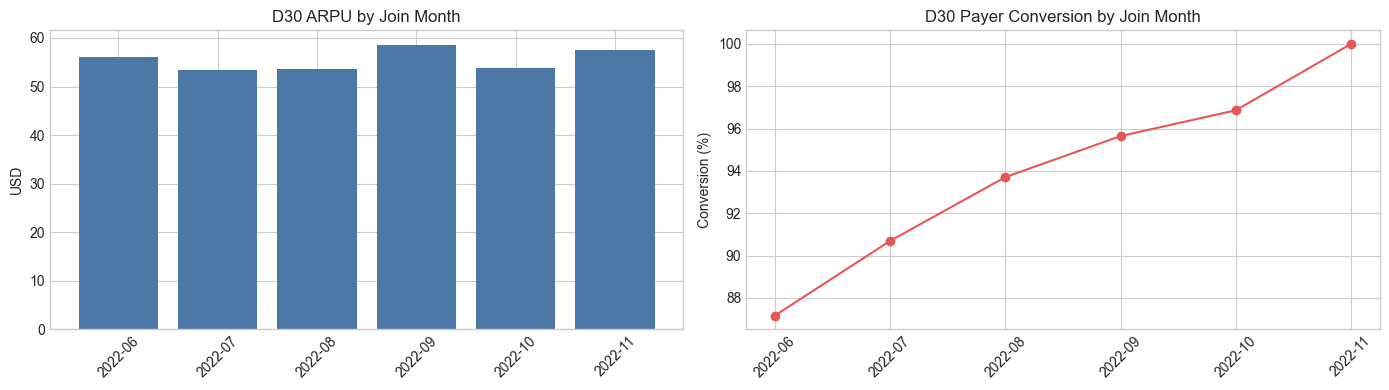

In [48]:
d30_users = lifecycle_users[
    lifecycle_users['join_date'] <= purchase_end - pd.Timedelta(days=29)
].copy()

d30_purchase_base = purchases_matched.merge(
    d30_users[['user_id', 'join_date']],
    on='user_id',
    how='inner'
)
d30_purchase_base['days_since_join'] = (
    d30_purchase_base['dt'] - d30_purchase_base['join_date']
).dt.days
d30_purchase_base = d30_purchase_base[
    d30_purchase_base['days_since_join'].between(0, 29)
].copy()

d30_user_revenue = (
    d30_users[['user_id', 'join_date']]
    .merge(
        d30_purchase_base
        .groupby('user_id')
        .agg(
            d30_revenue=('price_usd', 'sum'),
            d30_purchase_count=('price_usd', 'size'),
        )
        .reset_index(),
        on='user_id',
        how='left'
    )
)
d30_user_revenue['d30_revenue'] = d30_user_revenue['d30_revenue'].fillna(0)
d30_user_revenue['d30_purchase_count'] = d30_user_revenue['d30_purchase_count'].fillna(0).astype(int)
d30_user_revenue['is_d30_payer'] = d30_user_revenue['d30_revenue'].gt(0)

d30_summary_df = pd.DataFrame(
    {
        'metric': [
            'eligible users',
            'D30 paying users',
            'D30 payer conversion (%)',
            'D30 revenue',
            'D30 ARPU',
            'D30 ARPPU',
        ],
        'value': [
            d30_user_revenue['user_id'].nunique(),
            d30_user_revenue['is_d30_payer'].sum(),
            d30_user_revenue['is_d30_payer'].mean() * 100,
            d30_user_revenue['d30_revenue'].sum(),
            d30_user_revenue['d30_revenue'].sum() / d30_user_revenue['user_id'].nunique(),
            d30_user_revenue.loc[d30_user_revenue['is_d30_payer'], 'd30_revenue'].mean(),
        ],
    }
)

d30_cohort = (
    d30_user_revenue
    .assign(join_month=d30_user_revenue['join_date'].dt.to_period('M').dt.to_timestamp())
    .groupby('join_month')
    .agg(
        users=('user_id', 'nunique'),
        d30_payers=('is_d30_payer', 'sum'),
        d30_revenue=('d30_revenue', 'sum'),
    )
    .reset_index()
)
d30_cohort['d30_arpu'] = d30_cohort['d30_revenue'] / d30_cohort['users']
d30_cohort['d30_payer_conversion'] = d30_cohort['d30_payers'] / d30_cohort['users'] * 100
d30_cohort['month_label'] = d30_cohort['join_month'].dt.strftime('%Y-%m')

display(d30_summary_df.round(2))
display(d30_cohort[['month_label', 'users', 'd30_revenue', 'd30_arpu', 'd30_payer_conversion']].round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(d30_cohort['month_label'], d30_cohort['d30_arpu'], color='#4C78A8')
axes[0].set_title('D30 ARPU by Join Month')
axes[0].set_ylabel('USD')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(d30_cohort['month_label'], d30_cohort['d30_payer_conversion'], marker='o', color='#E45756')
axes[1].set_title('D30 Payer Conversion by Join Month')
axes[1].set_ylabel('Conversion (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Comment

- D30 ARPU is about 55.05 for users with a full 30-day window. This is much lower than the raw ARPU above, so observation length clearly matters.
- D30 payer conversion is about 92.48% in this cohort base. This is still high, but it is lower than the full-window payer conversion.
- D30 ARPU by join month stays in a fairly narrow range, around 53 to 59. Later cohorts look a bit stronger on D30 payer conversion than June and July, but the last cohort is smaller and should be read carefully.


## 11. Monetization by OS

This section brings the main OS monetization metrics together in one place.


In [49]:
os_full = (
    user_monetization
    .groupby('os')
    .agg(
        users=('user_id', 'nunique'),
        payers=('is_payer', 'sum'),
        revenue=('total_revenue', 'sum'),
    )
    .reset_index()
)
os_full['payer_conversion'] = os_full['payers'] / os_full['users']
os_full['ARPU'] = os_full['revenue'] / os_full['users']
os_full['ARPPU'] = os_full['revenue'] / os_full['payers']

os_payer_detail = (
    payers_only
    .groupby('os')
    .agg(
        avg_purchase_count=('purchase_count', 'mean'),
        avg_revenue_per_payer=('total_revenue', 'mean'),
    )
    .reset_index()
)

os_first_purchase = (
    lifecycle_payers
    .groupby('os')
    .agg(avg_days_to_first_purchase=('days_to_first_purchase', 'mean'))
    .reset_index()
)

os_monetization_summary = os_full.merge(os_payer_detail, on='os', how='left').merge(os_first_purchase, on='os', how='left')
display(os_monetization_summary.round(2))


,os,users,payers,revenue,payer_conversion,ARPU,ARPPU,avg_purchase_count,avg_revenue_per_payer,avg_days_to_first_purchase
0,Android,4266,4103,"437,833.48",0.96,102.63,106.71,23.28,106.71,8.88
1,iOS,2318,2167,"255,231.14",0.93,110.11,117.78,23.56,117.78,8.65


### Comment

- Android converts slightly better, but iOS has stronger ARPU and ARPPU. iOS also has a higher average purchase count per payer in this dataset.
- Average days to first purchase are close between the two platforms, so the bigger OS difference looks more like spend depth than purchase timing.


## 12. Monetization by country

To keep this section readable, I use only the top 5 countries by user count.


,country,users,payers,revenue,payer_conversion,ARPU,ARPPU,revenue_share,avg_purchase_count
3,United Kingdom,1531,1369,"150,413.24",0.89,98.25,109.87,0.34,21.73
4,United States,1439,1350,"185,716.37",0.94,129.06,137.57,0.42,27.03
1,Germany,418,412,"60,410.25",0.99,144.52,146.63,0.14,25.30
2,Spain,260,254,"27,159.42",0.98,104.46,106.93,0.06,22.99
0,Chile,237,220,"18,724.07",0.93,79.00,85.11,0.04,22.40


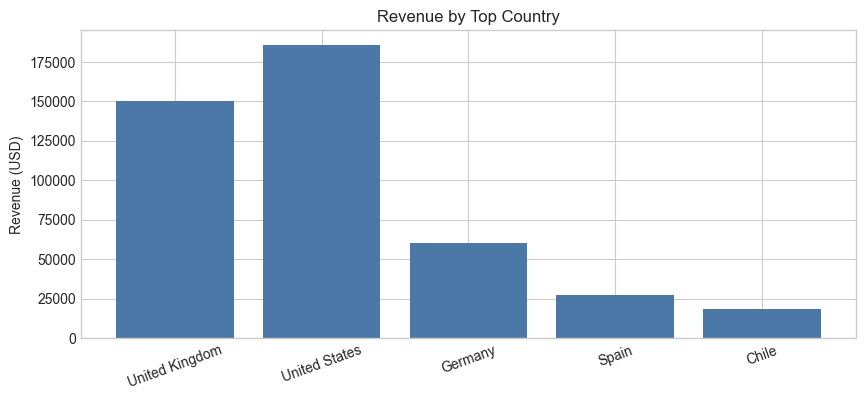

In [50]:
country_full = (
    user_monetization[user_monetization['country'].isin(top_country_list)]
    .groupby('country')
    .agg(
        users=('user_id', 'nunique'),
        payers=('is_payer', 'sum'),
        revenue=('total_revenue', 'sum'),
    )
    .reset_index()
)
country_full['payer_conversion'] = country_full['payers'] / country_full['users']
country_full['ARPU'] = country_full['revenue'] / country_full['users']
country_full['ARPPU'] = country_full['revenue'] / country_full['payers']
country_full['revenue_share'] = country_full['revenue'] / country_full['revenue'].sum()

country_payer_detail = (
    payers_only[payers_only['country'].isin(top_country_list)]
    .groupby('country')
    .agg(avg_purchase_count=('purchase_count', 'mean'))
    .reset_index()
)

country_monetization_summary = country_full.merge(country_payer_detail, on='country', how='left').sort_values('users', ascending=False)
display(country_monetization_summary.round(3))

plt.figure(figsize=(10, 4))
plt.bar(country_monetization_summary['country'], country_monetization_summary['revenue'], color='#4C78A8')
plt.title('Revenue by Top Country')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=20)
plt.show()


### Comment

- The United States and the United Kingdom are the biggest revenue contributors in the top-country group.
- The United States looks stronger than the United Kingdom on ARPU and ARPPU, even though the United Kingdom has more users.
- Germany has a smaller user base than the top two markets, but its value metrics are strong.


## 13. Payer segment overview

Here I split payers into low, mid, and high spend groups.

I do this by ranking payers by total revenue and then using the 33rd and 67th percentiles as cut points.


,spend_segment,payers,revenue,avg_purchase_count,avg_revenue,payer_share,revenue_share
0,low spenders,2069,"60,019.29",11.89,29.01,0.33,0.09
1,mid spenders,2132,"143,178.89",17.89,67.16,0.34,0.21
2,high spenders,2069,"489,866.44",40.51,236.76,0.33,0.71


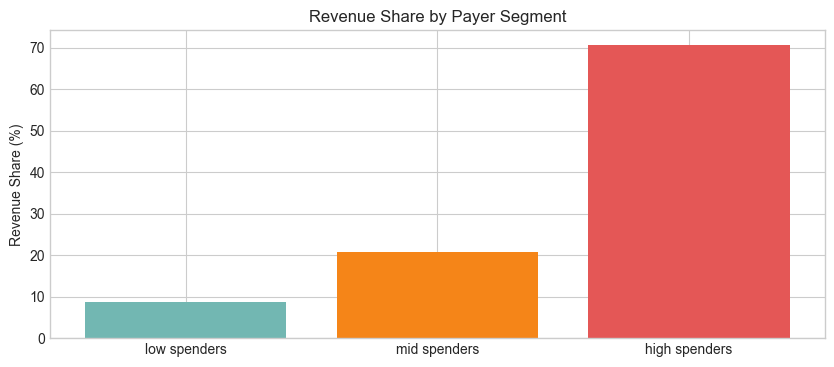

In [51]:
q1, q2 = payers_only['total_revenue'].quantile([0.33, 0.67]).values

payers_only['spend_segment'] = pd.cut(
    payers_only['total_revenue'],
    bins=[-np.inf, q1, q2, np.inf],
    labels=['low spenders', 'mid spenders', 'high spenders'],
)

spend_segment_df = (
    payers_only
    .groupby('spend_segment', observed=False)
    .agg(
        payers=('user_id', 'nunique'),
        revenue=('total_revenue', 'sum'),
        avg_purchase_count=('purchase_count', 'mean'),
        avg_revenue=('total_revenue', 'mean'),
    )
    .reset_index()
)
spend_segment_df['payer_share'] = spend_segment_df['payers'] / spend_segment_df['payers'].sum()
spend_segment_df['revenue_share'] = spend_segment_df['revenue'] / spend_segment_df['revenue'].sum()

display(spend_segment_df.round(3))

plt.figure(figsize=(10, 4))
plt.bar(spend_segment_df['spend_segment'], spend_segment_df['revenue_share'] * 100, color=['#72B7B2', '#F58518', '#E45756'])
plt.title('Revenue Share by Payer Segment')
plt.ylabel('Revenue Share (%)')
plt.show()


### Comment

- The payer groups are similar in size here, but revenue is not spread evenly across them.
- The `high spenders` group generates most of the revenue. This means a smaller high-value payer group is especially important for monetization.


## 14. Key findings

- In the matched registered-user base, total revenue is about 693K from about 147K purchases. Payer conversion is 95.23%, but this result comes from a selected user sample and should not be used as an overall benchmark.
- Cohort-based D30 ARPU is 55.05, and D30 payer conversion is 92.48% for users with a full 30-day window. This is much lower than raw ARPU, so observation length matters in the full-window view.
- Revenue trend looks more driven by payer and purchase volume than by big changes in spend per payer. Daily revenue and ARPDAU are stronger in summer and get weaker after early September.
- Android converts a little better than iOS, but iOS is stronger on spend depth. Android payer conversion is 96.18% vs 93.49%, while iOS ARPU and ARPPU are 110.11 and 117.78.
- The purchase base is very repeat-heavy. About 99% of payers are repeat purchasers, and the `4+ purchases` segment creates almost all revenue.
- First purchase usually happens early, but not only early. Median time to first purchase is 3 days, 54% of lifecycle payers buy by Day 3, and 32% still buy on Day 8+.
- Country value is not flat. The United States brings the largest revenue share at 42%, and Germany shows the strongest ARPU and ARPPU in the top-country group.